
Step size h = 0.1
Max global error: 0.040199
Total global error: 0.480047
Total local error: 0.101439


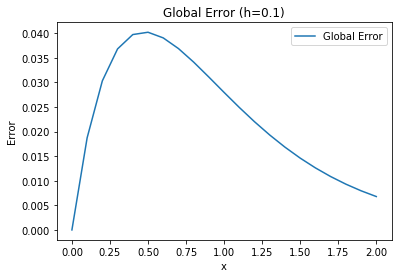

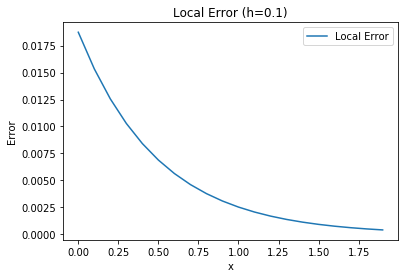


Step size h = 0.5
Max global error: 0.367879
Total global error: 0.571317
Total local error: 0.571317


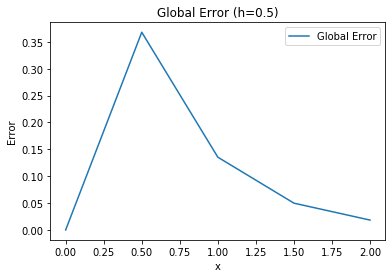

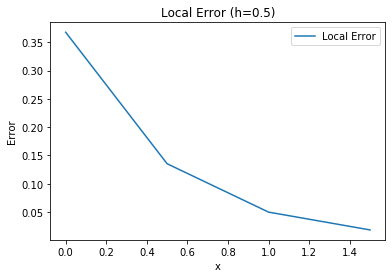


Step size h = 1
Max global error: 1.135335
Total global error: 2.117020
Total local error: 1.288986


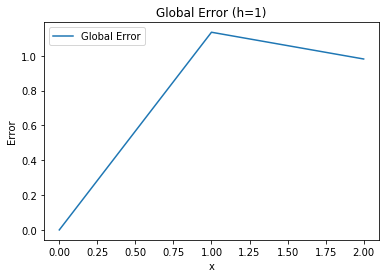

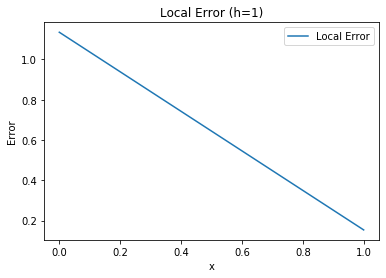


Step size h = 1.5
Max global error: 2.018316
Total global error: 2.018316
Total local error: 2.018316


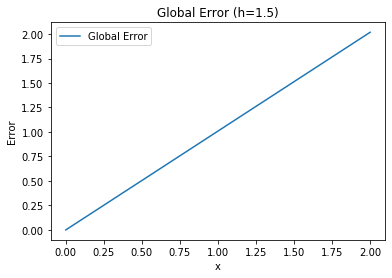

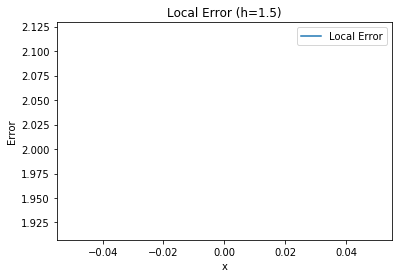

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ODE function
def f(x, y):
    return -2 * y

# exact solution
def y_exact(x):
    return np.exp(-2 * x)

# Euler method
def euler(h):
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h)

    x_vals = np.linspace(x_start, x_end, num_steps + 1)
    y_vals = np.zeros(num_steps + 1)
    y_vals[0] = 1

    for i in range(num_steps):
        y_vals[i+1] = y_vals[i] + h * f(x_vals[i], y_vals[i])

    return x_vals, y_vals

# local error (per step)
def local_error(x_vals, y_vals, h):
    local_err = np.zeros(len(x_vals) - 1)

    for i in range(len(x_vals) - 1):
        # exact next value from true solution
        y_true_next = y_exact(x_vals[i+1])

        # Euler step starting from TRUE value
        y_euler_step = y_exact(x_vals[i]) + h * f(x_vals[i], y_exact(x_vals[i]))

        local_err[i] = abs(y_true_next - y_euler_step)

    return local_err

# global error
def global_error(x_vals, y_vals):
    return np.abs(y_vals - y_exact(x_vals))

# step sizes to analyze
h_values = [0.1, 0.5, 1, 1.5]

for h in h_values:
    x_vals, y_vals = euler(h)

    g_error = global_error(x_vals, y_vals)
    l_error = local_error(x_vals, y_vals, h)

    print(f"\nStep size h = {h}")
    print(f"Max global error: {np.max(g_error):.6f}")
    print(f"Total global error: {np.sum(g_error):.6f}")
    print(f"Total local error: {np.sum(l_error):.6f}")

    # Plot global error
    plt.figure()
    plt.plot(x_vals, g_error, label="Global Error")
    plt.xlabel("x")
    plt.ylabel("Error")
    plt.title(f"Global Error (h={h})")
    plt.legend()
    plt.show()

    # Plot local error
    plt.figure()
    plt.plot(x_vals[:-1], l_error, label="Local Error")
    plt.xlabel("x")
    plt.ylabel("Error")
    plt.title(f"Local Error (h={h})")
    plt.legend()
    plt.show()